In [1]:
import os, numpy as np, agama, scipy.special, scipy.integrate, matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from IPython.display import Latex

agama.setUnits(length=1, velocity=1, mass=1)
#working in kiloparsec, km/s and M_sun



In [2]:
d_impact_array=np.flip(np.logspace(-5, -2, 20)) 
d_impact_array

array([1.00000000e-02, 6.95192796e-03, 4.83293024e-03, 3.35981829e-03,
       2.33572147e-03, 1.62377674e-03, 1.12883789e-03, 7.84759970e-04,
       5.45559478e-04, 3.79269019e-04, 2.63665090e-04, 1.83298071e-04,
       1.27427499e-04, 8.85866790e-05, 6.15848211e-05, 4.28133240e-05,
       2.97635144e-05, 2.06913808e-05, 1.43844989e-05, 1.00000000e-05])

In [3]:
d_impact = 0.005
print('b for this run is',d_impact,'kpc')

b for this run is 0.005 kpc


In [4]:
pot_sun_ideal = agama.Potential(dict(type='Plummer', mass =1, scaleRadius=2.2*1e-11))
pot_sun=agama.Potential(potential=pot_sun_ideal,center=[0,0,0])

In [5]:
pot_sun.potential([0,0,1]),agama.G

(-4.300917270677361e-06, 4.30091727067736e-06)

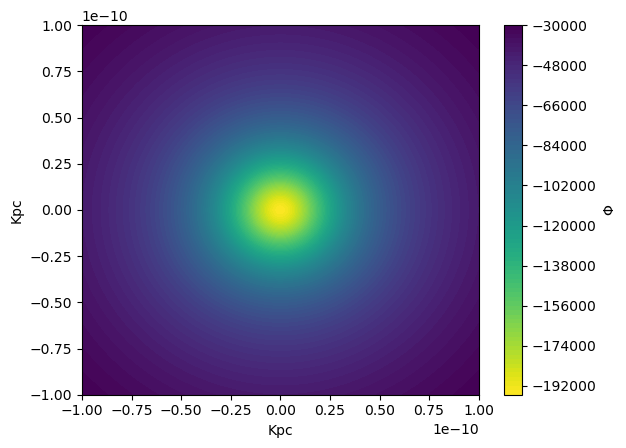

In [6]:
limit=1e-10
x = np.linspace(-1*limit, limit, 1000)
y = np.linspace(-1*limit, limit, 1000)
X, Y = np.meshgrid(x, y)

# Build (N, 3) array of points
points = np.c_[X.ravel(), Y.ravel(), np.zeros(X.size)]

# Evaluate potential
Z = pot_sun.potential(points).reshape(X.shape)

plt.contourf(X, Y, Z, levels=100, cmap='viridis_r')
plt.xlabel('Kpc')
plt.ylabel('Kpc')
plt.colorbar(label='Φ')
#plt.scatter(0.000025,0.000025,c='k')

In [7]:
mc_mass0=1e-6
mc_rvir=1e-2
mc_rs=1e-4
Nbody=10000


pot_mc_nfw  = agama.Potential(type='spheroid', gamma=1, beta=3, scaleradius=mc_rs, outercutoffradius=mc_rvir, mass=mc_mass0)
df_mc = agama.DistributionFunction(type='quasispherical', potential=pot_mc_nfw)
mc_mass0 = pot_mc_nfw.totalMass()
print('Minicluster mass in M_sun',mc_mass0)

mcp_xv, mcp_mass = agama.GalaxyModel(pot_mc_nfw, df_mc).sample(Nbody)

mcp_pot0=agama.Potential(type='multipole', particles=(mcp_xv[:,0:3] , mcp_mass), symmetry='n', lmax=10)
mcp_mass[0]



Minicluster mass in M_sun 1.0000000001817302e-06


np.float64(1.0028048120382304e-10)

Number of particles 10000
E_initial= 2.425072228958814e-05
test virial theorem: 2K/|U|= -1.0135047469207545


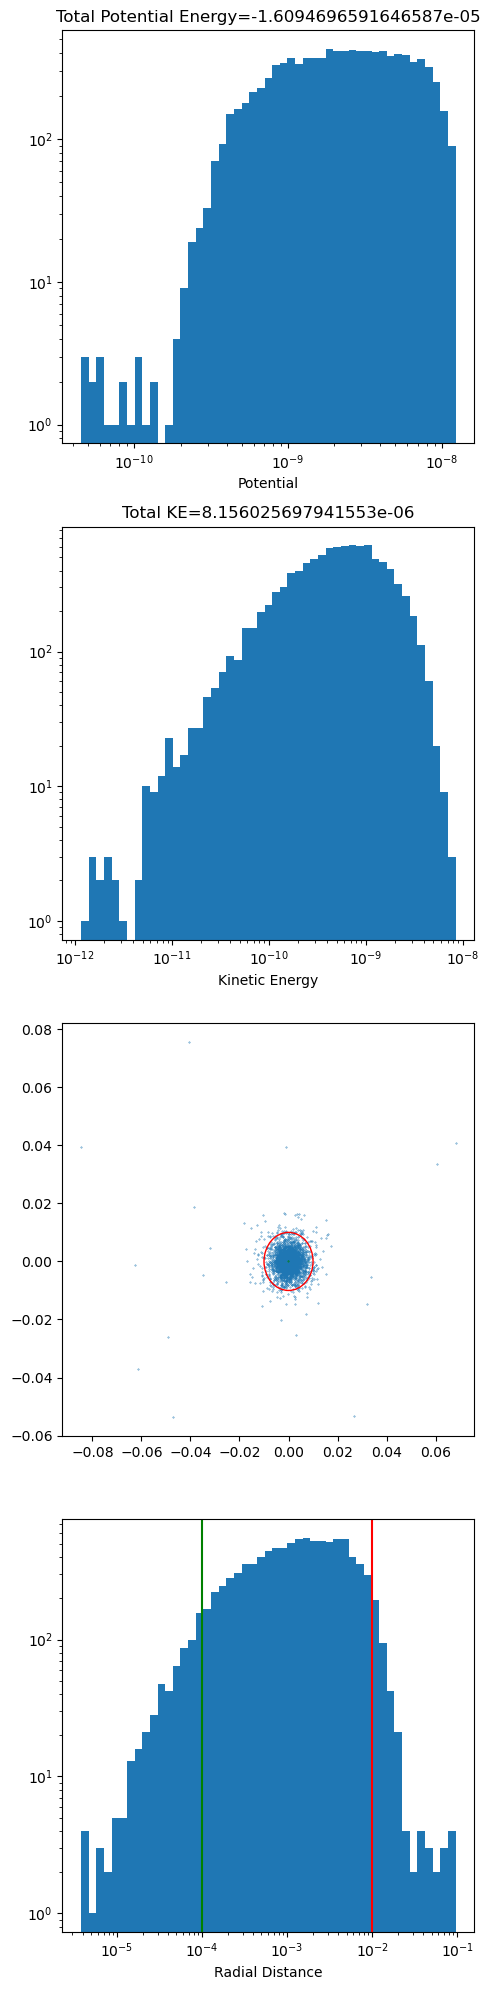

In [8]:
fig,axes=plt.subplots(4,1,figsize=(5,20))

print('Number of particles',Nbody)


ax=axes[0]
potential_initial_pos = -mcp_pot0.potential(mcp_xv[:,0:3])
ax.hist(potential_initial_pos, bins=np.logspace(np.log10(potential_initial_pos.min()), np.log10(potential_initial_pos.max()), 50))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Potential')
ax.set_title('Total Potential Energy='+str(-potential_initial_pos.sum()/2))
PE0=-potential_initial_pos.sum()/2

ax=axes[1]
kinetic_p_initial=0.5*np.sum(mcp_xv[:,3:6]**2,axis=1)
ax.hist(kinetic_p_initial, bins=np.logspace(np.log10(kinetic_p_initial.min()), np.log10(kinetic_p_initial.max()), 50))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Kinetic Energy')
ax.set_title('Total KE='+str(kinetic_p_initial.sum()))
KE0=kinetic_p_initial.sum()

ax=axes[2]
ax.scatter(mcp_xv[:,0], mcp_xv[:,1], s=0.1)
circle_vir = plt.Circle((0, 0), mc_rvir, color='r', fill=False)
ax.add_patch(circle_vir)
circle_rs = plt.Circle((0, 0), mc_rs, color='g', fill=True)
ax.add_patch(circle_rs)

ax=axes[3]
r_initial=np.sqrt(np.sum(mcp_xv[:,0:3]**2,axis=1))
ax.hist(r_initial, bins=np.logspace(np.log10(r_initial.min()), np.log10(r_initial.max()), 50))
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Radial Distance')
ax.axvline(mc_rs, color='g', label='Scale Radius')
ax.axvline(mc_rvir, color='r', label='Virial Radius')

plt.tight_layout()
E_initial= potential_initial_pos.sum()/2+kinetic_p_initial.sum()

print(  'E_initial=',E_initial)

print('test virial theorem: 2K/|U|=',2*KE0/PE0)

In [9]:

# ────────────────────────────────────────────────────────────
# FLYBY SETUP
# ────────────────────────────────────────────────────────────
# v_inf:    MC speed relative to Sun (typical DM velocity ~220 km/s)
# d_impact: closest approach distance (impact parameter for ~straight-line flyby)
# d_start:  starting distance from Sun

v_inf    = 220.0   # km/s
d_start  = 0.10    # kpc  (100 pc)

# MC centre starts at (-d_start, d_impact, 0), moving in +x direction
mc_ic = np.array([-d_start, d_impact, 0.0, v_inf, 0.0, 0.0])

# Shift particles into Sun frame:
#   mcp_xv contains particles centred at origin (from the earlier sampling cell)
mcp_xv_sim = mcp_xv.copy()
mcp_xv_sim[:, 0:3] += mc_ic[0:3]   # translate positions
mcp_xv_sim[:, 3:6] += mc_ic[3:6]   # add bulk velocity

# Initial MC self-gravity potential (particles relative to MC centre)
mc_sg = agama.Potential(type='multipole',
                        particles=(mcp_xv[:, 0:3], mcp_mass),
                        symmetry='n', lmax=10)



In [10]:
pot_total = agama.Potential(pot_sun, agama.Potential(potential=mcp_pot0, center=mc_ic[0:3]))

In [11]:

# ────────────────────────────────────────────────────────────
# SIMULATION: adaptive timestep (dt ∝ d_sun, flyby scaling)
# ────────────────────────────────────────────────────────────
# For a hyperbolic flyby at roughly constant speed v_inf,
sim_time  = 2 * d_start / v_inf    # total integration time [kpc/(km/s)]

tupd_max = sim_time / 50           # coarse step when MC is far (~d_start)
tupd_min = sim_time / 2000         # finest step allowed

def adaptive_dt(d_sun):
    """Linear scaling: dt ∝ d/v_inf (correct for constant-speed flyby)."""
    return float(np.clip(tupd_max * (d_sun / d_start), tupd_min, tupd_max))

# Accumulators
all_t      = []
d_sun_all  = []
bound_frac = []

t_flyby = (2 * d_start / v_inf)   


snap_interval = t_flyby / 9
snap_t, snap_xv_list, snap_mc_list, snap_sg_list, snap_bf = [], [], [], [], []
last_snap_t = -np.inf

mc_ic_cur  = mc_ic.copy()
mcp_xv_cur = mcp_xv_sim.copy()
mc_sg_cur  = mc_sg
t_cur      = 0.0
n_steps    = 0

# d at which tupd_min clamps in:  d_clamp = d_start * tupd_min/tupd_max
d_clamp_pc = d_start * (tupd_min / tupd_max)
print(f"Total sim time: {t_flyby:.3f} Gyr\n")

while t_cur < sim_time:
    d_sun = np.linalg.norm(mc_ic_cur[:3])
    tupd  = min(adaptive_dt(d_sun), sim_time - t_cur)

    # 1. Integrate MC centre in solar potential only
    t_mc, traj_mc = agama.orbit(ic=mc_ic_cur, potential=pot_sun,
                                 time=tupd, timestart=t_cur,
                                 trajsize=50, accuracy=1e-10)
    mc_ic_cur = traj_mc[-1]

    # 2. Total potential: Sun + MC self-gravity moving along its orbit
    pot_total = agama.Potential(
        pot_sun,
        agama.Potential(potential=mc_sg_cur,
                        center=np.column_stack((t_mc, traj_mc[:, 0:3])))
    )

    # 3. Integrate all particles for one timestep
    mcp_xv_cur = np.vstack(
        agama.orbit(ic=mcp_xv_cur, potential=pot_total,
                    time=tupd, timestart=t_cur, trajsize=1, accuracy=1e-10)[:, 1]
    )

    # 4. Rebuild MC self-gravity from updated particle positions
    dr = mcp_xv_cur[:, 0:3] - mc_ic_cur[0:3]
    mc_sg_cur = agama.Potential(type='multipole',
                                 particles=(dr, mcp_mass),
                                 symmetry='n', lmax=10)

    # 5. Bound/unbound: total energy in MC rest frame
    dv    = mcp_xv_cur[:, 3:6] - mc_ic_cur[3:6]
    E_int = 0.5 * np.sum(dv**2, axis=1) + mc_sg_cur.potential(dr)/2
    bound = E_int < 0
    print('Energy', E_int.sum())
    print('KE=',0.5 * np.sum(dv**2, axis=1).sum())
    print('PE=', mc_sg_cur.potential(dr).sum()/2)
    t_cur += tupd
    t_now  = t_cur 
    bf     = np.sum(mcp_mass[bound]) / np.sum(mcp_mass)

    all_t.append(t_now)
    d_sun_all.append(np.linalg.norm(mc_ic_cur[:3]))
    bound_frac.append(bf)
    n_steps += 1

    if t_now - last_snap_t >= snap_interval or t_cur >= sim_time:
        snap_t.append(t_now)
        snap_xv_list.append(mcp_xv_cur.copy())
        snap_mc_list.append(mc_ic_cur.copy())
        snap_sg_list.append(mc_sg_cur)
        snap_bf.append(bf)
        last_snap_t = t_now

all_t      = np.array(all_t)
d_sun_all  = np.array(d_sun_all)
bound_frac = np.array(bound_frac)
snap_t     = np.array(snap_t)
i_peri     = np.argmin(d_sun_all)



Total sim time: 0.001 Gyr

Energy -7.828909529102461e-06
KE= 8.265789e-06
PE= -1.6094698515935688e-05


10000 orbits complete (123457 orbits/s)
10000 orbits complete (128205 orbits/s)


Energy -7.828910471341736e-06
KE= 8.265788e-06
PE= -1.6094698563094593e-05
Energy -7.828911553877025e-06
KE= 8.265787e-06
PE= -1.6094698761671228e-05


10000 orbits complete (128205 orbits/s)
10000 orbits complete (129870 orbits/s)


Energy -7.828912744536294e-06
KE= 8.265786e-06
PE= -1.6094699088103408e-05
Energy -7.828913903904153e-06
KE= 8.265785e-06
PE= -1.6094699395089923e-05


...

10000 orbits complete (128205 orbits/s)
10000 orbits complete (133333 orbits/s)


Energy -7.516955020636194e-06
KE= 8.57775e-06
PE= -1.609470578176148e-05
Energy -7.5169525465249535e-06
KE= 8.577754e-06
PE= -1.6094706456953008e-05


10000 orbits complete (129870 orbits/s)
10000 orbits complete (128205 orbits/s)


Energy -7.516950088190901e-06
KE= 8.5777565e-06
PE= -1.609470681549323e-05
Energy -7.516948919188964e-06
KE= 8.577757e-06
PE= -1.60947068419784e-05


10000 orbits complete (129870 orbits/s)


In [12]:
E_final=E_int[bound].sum()
print('Energy final', E_final)
print('KE=',0.5 * np.sum(dv[bound]**2, axis=1).sum())
print('PE=', mc_sg_cur.potential(dr[bound]).sum()/2)
print('E initial=', E_initial)
print('E final=', E_final)


Energy final -8.232943676953444e-06
KE= 5.953796e-06
PE= -1.4186739593432991e-05
E initial= 2.425072228958814e-05
E final= -8.232943676953444e-06


In [13]:
print('Energy change', E_final - E_initial)


Energy change -3.2483665966541584e-05


In [14]:
E_delta_M=(E_final - E_initial)*mcp_mass[0]
print('Energy change per unit mass', E_delta_M)

Energy change per unit mass -3.2574776543890397e-15


In [15]:
E_theoretical= ((2*agama.G*1)/(d_impact**2*v_inf))**2*mc_mass0*0.13*(mc_rvir**2)*0.33
print('Theoretical energy change', E_theoretical)

Theoretical energy change 1.0493348153168354e-17


In [16]:
del_E_frac=E_theoretical/E_delta_M
print('E_theoretical/E_measured=',del_E_frac)

E_theoretical/E_measured= -0.003221310862725303


Number of particles 10000


NameError: name 'unbound' is not defined

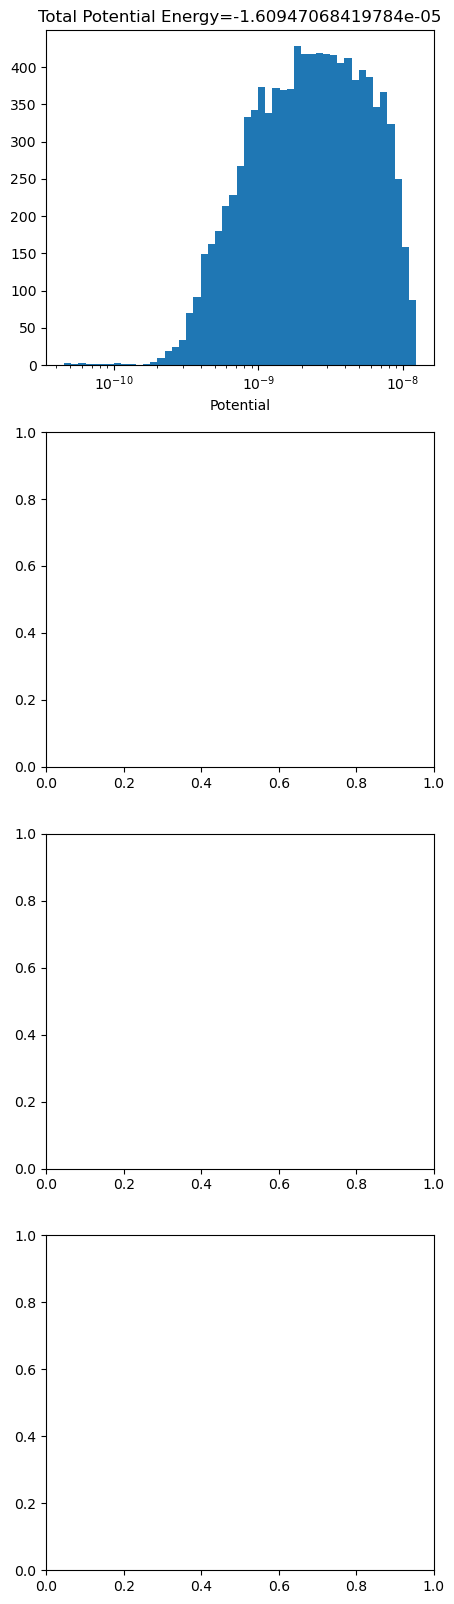

In [17]:
fig,axes=plt.subplots(4,1,figsize=(5,20))

print('Number of particles',Nbody)


ax=axes[0]
potential_final_pos = -mc_sg_cur.potential(dr)
ax.hist(potential_final_pos, bins=np.logspace(np.log10(potential_final_pos.min()), np.log10(potential_final_pos.max()), 50))
ax.set_xscale('log')
ax.set_xlabel('Potential')
ax.set_title('Total Potential Energy='+str(-potential_final_pos.sum()/2))
PE0=-potential_final_pos.sum()/2

ax=axes[1]
kinetic_p_final=0.5*np.sum(dv[bound]**2,axis=1)
my_array2ub=0.5*np.sum(dv[unbound]**2,axis=1)

ax.hist(kinetic_p_final, bins=np.logspace(np.log10(kinetic_p_final.min()), np.log10(kinetic_p_final.max()), 50))
ax.hist(my_array2ub, bins=np.logspace(np.log10(kinetic_p_final.min()), np.log10(kinetic_p_final.max()), 50),color='orange')
ax.hist(kinetic_p_initial, bins=np.logspace(np.log10(kinetic_p_initial.min()), np.log10(kinetic_p_initial.max()), 50),color='green',alpha=0.7)
ax.set_yscale('log')
ax.set_xscale('log')
ax.set_xlabel('Kinetic Energy')
ax.set_title('Total KE='+str(kinetic_p_final.sum()))
KE0=kinetic_p_final.sum()

ax=axes[2]
ax.scatter(dr[:,0], dr[:,1], s=0.1)
circle_vir = plt.Circle((0, 0), mc_rvir, color='r', fill=False)
ax.add_patch(circle_vir)
circle_rs = plt.Circle((0, 0), mc_rs, color='g', fill=True)
ax.add_patch(circle_rs)

ax=axes[3]
r_final=np.sqrt(np.sum(dr[:,0:3]**2,axis=1))
ax.hist(r_final, bins=np.logspace(np.log10(r_final.min()), np.log10(r_final.max()), 50))
ax.set_xscale('log')
ax.set_xlabel('Radial Distance')
ax.axvline(mc_rs, color='g', label='Scale Radius')
ax.axvline(mc_rvir, color='r', label='Virial Radius')

plt.tight_layout()
E_final= -potential_final_pos.sum()/2+kinetic_p_final.sum()

print(  'E_final=',E_final)

Perihelion: 0.01 pc at t = 0.000 Myr
Bound mass: initial=86.1%  at perihelion=85.1%  final=83.5%
Total mass loss: 16.5%


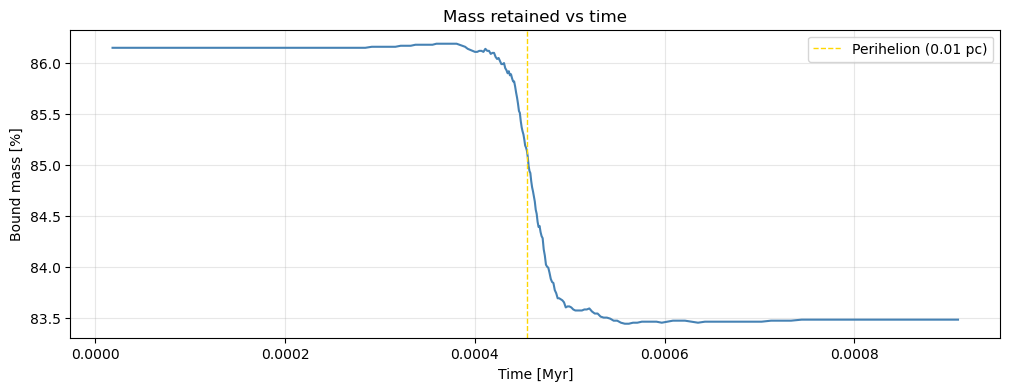

In [18]:

# ────────────────────────────────────────────────────────────
# PLOT: bound fraction and MC–Sun distance over time
# ────────────────────────────────────────────────────────────
i_peri    = np.argmin(d_sun_all)
t_peri    = all_t[i_peri]
d_peri_pc = d_sun_all[i_peri]

fig, ax1 = plt.subplots( figsize=(12, 4))

ax1.plot(all_t, bound_frac * 100, 'steelblue', lw=1.5)
ax1.axvline(t_peri, color='gold', ls='--', lw=1, label=f'Perihelion ({d_peri_pc:.2f} pc)')
ax1.set_xlabel('Time [Myr]')
ax1.set_ylabel('Bound mass [%]')
ax1.set_title('Mass retained vs time')
ax1.legend()
ax1.grid(alpha=0.3)



print(f"Perihelion: {d_peri_pc:.2f} pc at t = {t_peri:.3f} Myr")
print(f"Bound mass: initial={bound_frac[0]:.1%}  at perihelion={bound_frac[i_peri]:.1%}  final={bound_frac[-1]:.1%}")
print(f"Total mass loss: {(1 - bound_frac[-1]) * 100:.1f}%")


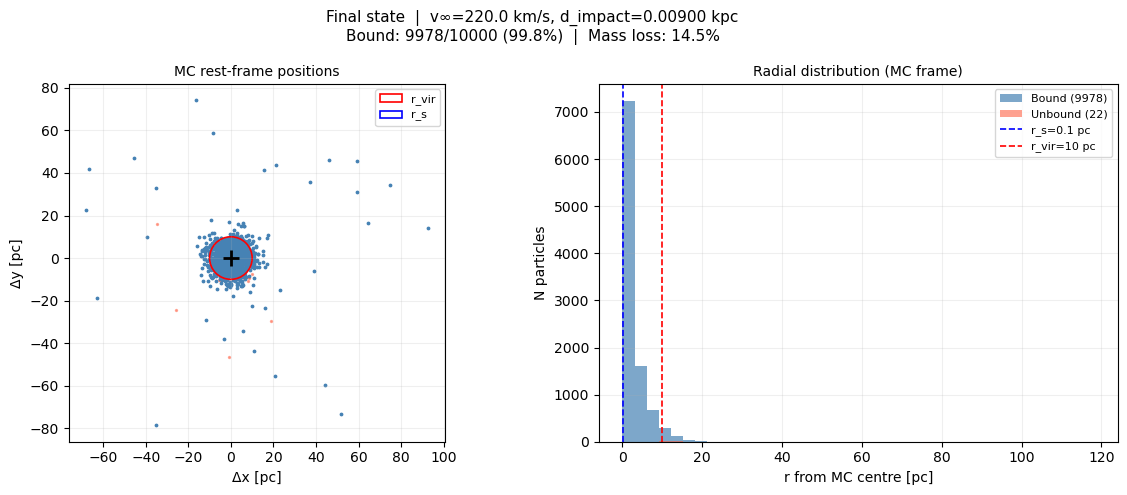

In [ ]:

# ────────────────────────────────────────────────────────────
# PLOT: final particle distribution
# ────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

xv_fin  = snap_xv_list[-1]
mc_fin  = snap_mc_list[-1]
sg_fin  = snap_sg_list[-1]

dr_fin  = xv_fin[:, 0:3] - mc_fin[0:3]
dv_fin  = xv_fin[:, 3:6] - mc_fin[3:6]
E_int   = 0.5 * np.sum(dv_fin**2, axis=1) + sg_fin.potential(dr_fin)
bound   = E_int < 0
unbound = ~bound

r_fin   = np.linalg.norm(dr_fin, axis=1) * 1e3  # pc, MC-centred

fig, axes = plt.subplots(1,2 , figsize=(12, 5))

# ── Panel 1: sky-plane positions (Sun frame) ──────────────────


# ── Panel 2: MC rest-frame positions ─────────────────────────
ax = axes[0]
ax.scatter(dr_fin[unbound, 0]*1e3, dr_fin[unbound, 1]*1e3,
           s=2, c='tomato', alpha=0.5)
ax.scatter(dr_fin[bound,   0]*1e3, dr_fin[bound,   1]*1e3,
           s=3, c='steelblue')
ax.plot(0, 0, 'k+', ms=12, mew=2, zorder=5)
for rv, lbl, col in [(mc_rvir*1e3,'r_vir','r'), (mc_rs*1e3,'r_s','b')]:
    circ = plt.Circle((0,0), rv, color=col, fill=False, lw=1.2, label=lbl)
    ax.add_patch(circ)
ax.set_xlabel('Δx [pc]')
ax.set_ylabel('Δy [pc]')
ax.set_title('MC rest-frame positions', fontsize=10)
ax.legend(fontsize=8)
ax.set_aspect('equal')
ax.grid(alpha=0.2)

# ── Panel 3: radial distribution (MC-centred) ─────────────────
ax = axes[1]
r_max = max(r_fin.max(), mc_rvir*1e3)
bins  = np.linspace(0, r_max, 40)
ax.hist(r_fin[bound],   bins=bins, color='steelblue', alpha=0.7,
        label=f'Bound ({bound.sum()})')
ax.hist(r_fin[unbound], bins=bins, color='tomato',    alpha=0.6,
        label=f'Unbound ({unbound.sum()})')
ax.axvline(mc_rs*1e3,  color='b', ls='--', lw=1.2, label=f'r_s={mc_rs*1e3:.1f} pc')
ax.axvline(mc_rvir*1e3,color='r', ls='--', lw=1.2, label=f'r_vir={mc_rvir*1e3:.0f} pc')
ax.set_xlabel('r from MC centre [pc]')
ax.set_ylabel('N particles')
ax.set_title('Radial distribution (MC frame)', fontsize=10)
ax.legend(fontsize=8)
ax.grid(alpha=0.2)

fig.suptitle(
    f'Final state  |  v∞={v_inf} km/s, d_impact={d_impact:.5f} kpc\n'
    f'Bound: {bound.sum()}/{Nbody} ({bound.sum()/Nbody:.1%})  |  '
    f'Mass loss: {(1-bound_frac[-1])*100:.1f}%',
    fontsize=11)
plt.tight_layout()
plt.show()


In [ ]:
E_theoretical_array.append(E_theoretical/mcp_mass[0])
E_measured_array.append(E_final)
b_array.append(d_impact)
Mass_loss_fraction_array.append((1-bound_frac[-1])*100)


NameError: name 'E_theoretical_array' is not defined

In [ ]:
E_measured_array[0]

In [ ]:
E_theoretical_array

In [ ]:
b_array 

In [ ]:
Mass_loss_fraction_array

In [ ]:
E_theoretical_array=[]
E_measured_array=[]
b_array=[]
Mass_loss_fraction_array=[]